# Session 4 <br> Parameter-Efficient Fine-Tuning  (PEFT)

Parameter-Efficient Fine-Tuning or PEFT is an approach to fine-tuning models in which most of the model weights are kept intact, as oposed to Full Fine-Tuning (FFT) where all the weights are trained. This can be done to overcome computational limitations (especially memory ones) or to preserve part of the _knowledge_ previously _acquired_ by the model during training.

Some PEFT techniques includes:

* Freezing Layers
* Prefix Tuning
* Low Rank Adapters (LoRA)

In this Session, we will repeat the Document Classification Task from Session 3 using different PEFT approach and we will compare the results with those obtained with FFT.

## Before Training

We will need to set up some thing before we start training our models.

### Install and Update libraries

In [3]:
# ! pip install torch -U --quiet
# ! pip install torchvision -U --quiet
# ! pip install torchaudio -U --quiet
# ! pip install transformers -U --quiet
%pip install peft==0.14 
# ! pip install datasets -U --quiet
# ! pip install nltk -U --quiet
# ! pip install scikit-learn -U --quiet
# ! pip install tqdm -U --quiet
# ! pip install matplotlib -U --quiet

  Using cached peft-0.14.0-py3-none-any.whl (374 kB)
     |████████████████████████████████| 362 kB 4.5 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
! pip list

Package                  Version
------------------------ ---------
-orch                    2.6.0
accelerate               1.6.0
appdirs                  1.4.4
attrs                    20.3.0
backcall                 0.2.0
bcrypt                   3.1.7
beautifulsoup4           4.9.3
Bottleneck               1.2.1
cephfs                   2.0.0
certifi                  2025.4.26
cffi                     1.14.5
chardet                  4.0.0
charset-normalizer       3.4.2
ClusterShell             1.8.3
contourpy                1.3.0
cryptography             3.3.2
cycler                   0.10.0
Cython                   0.29.21
decorator                4.4.2
defusedxml               0.6.0
distlib                  0.3.1
et-xmlfile               1.0.1
filelock                 3.18.0
fonttools                4.57.0
fsspec                   2025.3.2
GDAL                     3.2.2
git-cola                 3.9
hf-xet                   1.1.0
html5lib                 1.1
httplib2               

### Import libraries

In [1]:
import numpy as np
import torch
from transformers import AutoTokenizer, DataCollatorWithPadding, TrainerCallback, TrainingArguments, AutoModelForSequenceClassification, Trainer

/home/solga/venvNER/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
 import tqdm as notebook_tqdm

In [2]:
import os
from datasets import Dataset
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.metrics import classification_report
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random
import numpy as np
import gc

nltk.download('punkt_tab')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

[nltk_data] Downloading package punkt_tab to /home/solga/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
from peft import PrefixTuningConfig, LoraConfig, get_peft_model, TaskType

### Logging Memory Ussage

Before starting to train our models, we will create a TrainerCallback class that, at every training step will record the memmory ussage. THis will help us compare each PEFT approach.

In [4]:
class MemoryLoggerCallback(TrainerCallback):
    def __init__(self, model):
        self.memory_allocated = []
        self.memory_reserved = []
        self.model = model

    def on_step_end(self, args, state, control, **kwargs):
        # GPU memory usage
        allocated = torch.cuda.memory_allocated() / 1024 ** 2  # Convert to MB
        reserved = torch.cuda.memory_reserved() / 1024 ** 2    # Convert to MB
        self.memory_allocated.append(allocated)
        self.memory_reserved.append(reserved)

### Evaluating Performance

We will also need a function to compute the performance of our models.
We will use scikit-learn classification report for that.

In [5]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    report = classification_report(labels, predictions, output_dict=True, zero_division=0.0)
    for k in list(report.keys()):
        if isinstance(report[k], dict):
            for vk in report[k]:
                report[f'{k}_{vk}'] = report[k][vk]
            del report[k]
    return report

### Get the Tokenizer

We will need a tokenizer to turn the text from string to integer tokens.



In [6]:
# Select Base Model
base_model_path = 'google-bert/bert-base-cased'

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(base_model_path)

### Prepare Data

We also need to prepare our Training, Validation, and Test Data.

First we need to upload the dataset to our virutal machine in colab, then we need to read the content of the files, after that we need to create the Train, Validation, and Test split, and finally we will apply the tokenizer to the dataset.

In [7]:
!unzip -qq wkp.zip

In [10]:
categories = ['Airports', 'Artists', 'Astronauts', 'Astronomical_objects', 'Building', 'City', 'Comics_characters', 'Companies', 'Foods', 'Monuments_and_memorials', 'Politicians', 'Sports_teams', 'Sportspeople', 'Transport', 'Universities_and_colleges', 'Written_communication']
data = {
    'text':[],
    'label':[]
}
for c, cat in enumerate(categories):
    for file_name in os.listdir(f'wkp_sorted/{cat}'):
        if file_name.endswith('.txt'):
            with open(f'wkp_sorted/{cat}/{file_name}', 'r', encoding='utf-8') as file:
                for sentence in sent_tokenize(file.read().strip()):
                    data['text'].append(sentence)
                    data['label'].append(c)

ds = Dataset.from_dict(data)

# Generate a test and validation splits from the training split
ds = ds.train_test_split(test_size=0.15, shuffle=True, seed=42)
temp_ds = ds['train'].train_test_split(test_size=0.05, shuffle=True, seed=42)
ds['train'] = temp_ds['train']
ds['validation'] = temp_ds['test']

# # Take a smaller subset of the data
ds['train'] = ds['train'].take(2**12)
ds['validation'] = ds['validation'].take(2**8)
ds['test'] = ds['test'].take(2**10)

# # Tokenize dataset
tokenizer.model_max_length = 504 # We reduce th maximum sequence size on 8 tokens to have space for the Prefix Tuning
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True)

tokenized_ds = ds.map(preprocess_function, batched=True).remove_columns(['text'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map: 100%|██████████| 256/256 [00:00<00:00, 20309.48 examples/s]


### Set Training Arguments

We will use the same training arguments on all experiments for comparability.

In [11]:
# Set training arguments
training_args = TrainingArguments(
    eval_strategy = 'steps',
    logging_steps = 64,
    eval_steps = 64,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 16,
    num_train_epochs = 1,
    report_to = []
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Experiments

Now we an run our 4 experiments:

### Full Fine-Tuning

First we will train our model using Full Fine-Tunning as a point of comparison.

In [12]:
# Load Model
torch.cuda.empty_cache()
gc.collect()
fft_model = AutoModelForSequenceClassification.from_pretrained(base_model_path, num_labels=len(categories))

# Iterate over all layers of the model
trainable_params = 0
all_params = 0
for name, parameter in fft_model.named_parameters():
    all_params += parameter.numel()
    if parameter.requires_grad:
        trainable_params += parameter.numel()
print(f'trainable params: {trainable_params:,.2f} || all params: {all_params:,.2f} || trainable%: {100*trainable_params/all_params}')

# Set memory logger
fft_memory_logger = MemoryLoggerCallback(model=fft_model)

# Set Trainer
trainer = Trainer(
    model=fft_model,
    args=training_args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
    callbacks=[fft_memory_logger],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Run Training
trainer.train()

# Move the model to CPU and empty the GPU cache to avoid interfeering with the meassurement of future models
fft_model.to('cpu')
torch.cuda.empty_cache()
gc.collect()

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 108,322,576.00 || all params: 108,322,576.00 || trainable%: 100.0


Step,Training Loss,Validation Loss,Accuracy,0 Precision,0 Recall,0 F1-score,0 Support,1 Precision,1 Recall,1 F1-score,1 Support,2 Precision,2 Recall,2 F1-score,2 Support,3 Precision,3 Recall,3 F1-score,3 Support,4 Precision,4 Recall,4 F1-score,4 Support,5 Precision,5 Recall,5 F1-score,5 Support,6 Precision,6 Recall,6 F1-score,6 Support,7 Precision,7 Recall,7 F1-score,7 Support,8 Precision,8 Recall,8 F1-score,8 Support,9 Precision,9 Recall,9 F1-score,9 Support,10 Precision,10 Recall,10 F1-score,10 Support,11 Precision,11 Recall,11 F1-score,11 Support,12 Precision,12 Recall,12 F1-score,12 Support,13 Precision,13 Recall,13 F1-score,13 Support,14 Precision,14 Recall,14 F1-score,14 Support,15 Precision,15 Recall,15 F1-score,15 Support,Macro avg Precision,Macro avg Recall,Macro avg F1-score,Macro avg Support,Weighted avg Precision,Weighted avg Recall,Weighted avg F1-score,Weighted avg Support
64,2.518900,2.217022,0.347656,0.517241,0.625000,0.566038,24.000000,0.000000,0.000000,0.000000,16.000000,0.333333,0.038462,0.068966,26.000000,1.000000,0.538462,0.700000,13.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,0.282609,1.000000,0.440678,26.000000,1.000000,0.357143,0.526316,14.000000,0.410256,0.842105,0.551724,19.000000,0.234568,0.863636,0.368932,22.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.236125,0.266550,0.201416,256.000000,0.267124,0.347656,0.241810,256.000000
128,1.797700,1.360333,0.687500,0.785714,0.916667,0.846154,24.000000,0.333333,0.687500,0.448980,16.000000,0.487179,0.730769,0.584615,26.000000,0.800000,0.923077,0.857143,13.000000,0.666667,0.666667,0.666667,12.000000,1.000000,0.791667,0.883721,24.000000,0.923077,0.923077,0.923077,26.000000,0.714286,0.714286,0.714286,14.000000,0.818182,0.947368,0.878049,19.000000,0.633333,0.863636,0.730769,22.000000,0.666667,0.333333,0.444444,12.000000,0.666667,0.500000,0.571429,8.000000,1.000000,0.600000,0.750000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.593444,0.599878,0.581208,256.000000,0.648708,0.687500,0.653157,256.000000
192,1.216200,0.986900,0.753906,0.560976,0.958333,0.707692,24.000000,0.608696,0.875000,0.717949,16.000000,0.615385,0.923077,0.738462,26.000000,0.923077,0.923077,0.923077,13.000000,0.714286,0.416667,0.526316,12.000000,0.814815,0.916667,0.862745,24.000000,0.925926,0.961538,0.943396,26.000000,0.650000,0.928571,0.764706,14.000000,0.809524,0.894737,0.850000,19.000000,1.000000,0.772727,0.871795,22.000000,1.000000,0.333333,0.500000,12.000000,1.000000,0.500000,0.666667,8.000000,1.000000,0.900000,0.947368,10.000000,0.000000,0.000000,0.000000,17.000000,1.000000,0.500000,0.666667,8.000000,0.000000,0.000000,0.000000,5.000000,0.726418,0.675233,0.667927,256.000000,0.733924,0.753906,0.716396,256.000000
256,0.938200,0.801071,0.781250,0.800000,1.000000,0.888889,24.000000,0.619048,0.812500,0.702703,16.000000,0.641026,0.961538,0.769231,26.000000,1.000000,0.769231,0.869565,13.000000,0.833333,0.416667,0.555556,12.000000,1.000000,0.916667,0.956522,24.000000,0.888889,0.923077,0.905660,26.000000,0.666667,0.857143,0.750000,14.000000,0.818182,0.947368,0.878049,19.000000,0.750000,0.818182,0.782609,22.000000,1.000000,0.333333,0.500000,12.000000,0.600000,0.750000,0.666667,8.000000,1.000000,0.800000,0.888889,10.000000,0.555556,0.294118,0.384615,17.000000,1.000000,0.625000,0.769231,8.000000,1.000000,0.200000,0.333333,5.000000,0.823294,0.714051,0.725095,256.000000,0.806663,0.781250,0.765753,256.000000
320,0.821500,0.692476,0.796875,0.833333,0.833333,0.833333,24.000000,0.687500,0.687500,0.687500,16.000000,0.793103,0.884615,0.836364,26.000000,0.800000,0.923077,0.857143,13.000000,0.750000,0.500000,0.600000,12.000000,0.851852,0.958333,0.901961,24.000000,0.923077,0.923077,0.923077,26.000000,0.705882,0.857143,0.774194,

715

### Freezing Layers

Now we will try a different approach where we freeze the first 10 layers of the model.

In [13]:
# Load Model

torch.cuda.empty_cache()
gc.collect()
frozen_model = AutoModelForSequenceClassification.from_pretrained(base_model_path, num_labels=len(categories))

"""
WRITE HERE YOUR CODE TO FREEZE THE FIRST 10 LAYERS OF THE MODEL
PRINT THE COUNT OF TRAINABLE PARAMETERS AND ALL PARAMETERS AS WELL AS THE PERCENTAGE OF TRAINABLE PARAMETERS
"""

# This assumes the model has a .encoder.layer or .bert.encoder.layer structure
try:
    encoder_layers = frozen_model.bert.encoder.layer
except AttributeError:
    encoder_layers = frozen_model.base_model.encoder.layer  # fallback for e.g., RoBERTa, DistilBERT

for i in range(10):
    for param in encoder_layers[i].parameters():
        param.requires_grad = False

# Count parameters
total_params = sum(p.numel() for p in frozen_model.parameters())
trainable_params = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
percent_trainable = 100 * trainable_params / total_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {percent_trainable:.2f}%")



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 108,322,576
Trainable parameters: 37,443,856
Percentage trainable: 34.57%


In [14]:
# Set memory logger
frozen_memory_logger = MemoryLoggerCallback(model=frozen_model)

# Set Trainer
trainer = Trainer(
    model=frozen_model,
    args=training_args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
    callbacks=[frozen_memory_logger],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Run Training
trainer.train()

# Move the model to CPU and empty the GPU cache to avoid interfeering with the meassurement of future models
frozen_model.to('cpu')
torch.cuda.empty_cache()
gc.collect()

Step,Training Loss,Validation Loss,Accuracy,0 Precision,0 Recall,0 F1-score,0 Support,1 Precision,1 Recall,1 F1-score,1 Support,2 Precision,2 Recall,2 F1-score,2 Support,3 Precision,3 Recall,3 F1-score,3 Support,4 Precision,4 Recall,4 F1-score,4 Support,5 Precision,5 Recall,5 F1-score,5 Support,6 Precision,6 Recall,6 F1-score,6 Support,7 Precision,7 Recall,7 F1-score,7 Support,8 Precision,8 Recall,8 F1-score,8 Support,9 Precision,9 Recall,9 F1-score,9 Support,10 Precision,10 Recall,10 F1-score,10 Support,11 Precision,11 Recall,11 F1-score,11 Support,12 Precision,12 Recall,12 F1-score,12 Support,13 Precision,13 Recall,13 F1-score,13 Support,14 Precision,14 Recall,14 F1-score,14 Support,15 Precision,15 Recall,15 F1-score,15 Support,Macro avg Precision,Macro avg Recall,Macro avg F1-score,Macro avg Support,Weighted avg Precision,Weighted avg Recall,Weighted avg F1-score,Weighted avg Support
64,2.461700,2.097264,0.468750,0.477273,0.875000,0.617647,24.000000,0.000000,0.000000,0.000000,16.000000,1.000000,0.076923,0.142857,26.000000,1.000000,0.615385,0.761905,13.000000,0.000000,0.000000,0.000000,12.000000,0.739130,0.708333,0.723404,24.000000,0.367647,0.961538,0.531915,26.000000,0.900000,0.642857,0.750000,14.000000,0.894737,0.894737,0.894737,19.000000,0.227848,0.818182,0.356436,22.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,8.000000,1.000000,0.300000,0.461538,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.412915,0.368310,0.327527,256.000000,0.477989,0.468750,0.389027,256.000000
128,1.677700,1.361140,0.667969,0.750000,0.875000,0.807692,24.000000,0.421053,0.500000,0.457143,16.000000,0.452381,0.730769,0.558824,26.000000,0.923077,0.923077,0.923077,13.000000,0.727273,0.666667,0.695652,12.000000,0.740741,0.833333,0.784314,24.000000,0.892857,0.961538,0.925926,26.000000,0.611111,0.785714,0.687500,14.000000,0.818182,0.947368,0.878049,19.000000,0.513514,0.863636,0.644068,22.000000,0.750000,0.250000,0.375000,12.000000,1.000000,0.250000,0.400000,8.000000,1.000000,0.400000,0.571429,10.000000,0.000000,0.000000,0.000000,17.000000,1.000000,0.125000,0.222222,8.000000,0.000000,0.000000,0.000000,5.000000,0.662512,0.569506,0.558181,256.000000,0.658658,0.667969,0.625559,256.000000
192,1.172200,1.032690,0.710938,0.638889,0.958333,0.766667,24.000000,0.521739,0.750000,0.615385,16.000000,0.480000,0.923077,0.631579,26.000000,1.000000,0.923077,0.960000,13.000000,0.666667,0.500000,0.571429,12.000000,0.785714,0.916667,0.846154,24.000000,0.892857,0.961538,0.925926,26.000000,0.687500,0.785714,0.733333,14.000000,0.894737,0.894737,0.894737,19.000000,0.789474,0.681818,0.731707,22.000000,0.800000,0.333333,0.470588,12.000000,1.000000,0.250000,0.400000,8.000000,1.000000,0.500000,0.666667,10.000000,0.000000,0.000000,0.000000,17.000000,1.000000,0.500000,0.666667,8.000000,0.000000,0.000000,0.000000,5.000000,0.697349,0.617393,0.617552,256.000000,0.698539,0.710938,0.674209,256.000000
256,0.972500,0.904506,0.730469,0.733333,0.916667,0.814815,24.000000,0.600000,0.750000,0.666667,16.000000,0.489362,0.884615,0.630137,26.000000,1.000000,0.923077,0.960000,13.000000,0.714286,0.416667,0.526316,12.000000,0.884615,0.958333,0.920000,24.000000,0.892857,0.961538,0.925926,26.000000,0.625000,0.714286,0.666667,14.000000,0.900000,0.947368,0.923077,19.000000,0.750000,0.818182,0.782609,22.000000,0.800000,0.333333,0.470588,12.000000,0.750000,0.375000,0.500000,8.000000,0.857143,0.600000,0.705882,10.000000,0.428571,0.176471,0.250000,17.000000,1.000000,0.375000,0.545455,8.000000,0.000000,0.000000,0.000000,5.000000,0.714073,0.634409,0.643009,256.000000,0.733387,0.730469,0.706892,256.000000
320,0.846200,0.798928,0.765625,0.826087,0.791667,0.808511,24.000000,0.500000,0.750000,0.600000,16.000000,0.766667,0.884615,0.821429,26.000000,1.000000,0.923077,0.960000,13.000000,0.714286,0.416667,0.526316,12.000000,0.821429,0.958333,0.884615,24.000000,0.892857,0.961538,0.925926,26.000000,0.647059,0.785714,0.709677,

544

### Prefix Tuning

In [15]:
# Load Model
torch.cuda.empty_cache()
gc.collect()
prefix_model = AutoModelForSequenceClassification.from_pretrained(base_model_path, num_labels=len(categories))

"""
WRITE HERE YOUR CODE TO APPLY PREFIX TUNNING (USE 8 VIRTUAL TOKENS AND A TOKEN DIMENSION OF 768)
PRINT THE COUNT OF TRAINABLE PARAMETERS AND ALL PARAMETERS AS WELL AS THE PERCENTAGE OF TRAINABLE PARAMETERS
"""

# Define Prefix Tuning config
prefix_config = PrefixTuningConfig(
    task_type=TaskType.SEQ_CLS,
    num_virtual_tokens=8,
    encoder_hidden_size=768,
)

# Apply Prefix Tuning
prefix_model = get_peft_model(prefix_model, prefix_config)

# Count parameters
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pct_trainable = 100 * trainable / total
    print(f"Trainable parameters: {trainable}")
    print(f"Total parameters:     {total}")
    print(f"Percentage:           {pct_trainable:.4f}%")

count_parameters(prefix_model)

# Set memory logger
prefix_memory_logger = MemoryLoggerCallback(model=prefix_model)

# Set Trainer
trainer = Trainer(
    model=prefix_model,
    args=training_args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
    callbacks=[prefix_memory_logger],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Run Training
trainer.train()

# Move the model to CPU and empty the GPU cache to avoid interfeering with the meassurement of future models
prefix_model.to('cpu')
torch.cuda.empty_cache()
gc.collect()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainable parameters: 159760
Total parameters:     108482336
Percentage:           0.1473%


Step,Training Loss,Validation Loss,Accuracy,0 Precision,0 Recall,0 F1-score,0 Support,1 Precision,1 Recall,1 F1-score,1 Support,2 Precision,2 Recall,2 F1-score,2 Support,3 Precision,3 Recall,3 F1-score,3 Support,4 Precision,4 Recall,4 F1-score,4 Support,5 Precision,5 Recall,5 F1-score,5 Support,6 Precision,6 Recall,6 F1-score,6 Support,7 Precision,7 Recall,7 F1-score,7 Support,8 Precision,8 Recall,8 F1-score,8 Support,9 Precision,9 Recall,9 F1-score,9 Support,10 Precision,10 Recall,10 F1-score,10 Support,11 Precision,11 Recall,11 F1-score,11 Support,12 Precision,12 Recall,12 F1-score,12 Support,13 Precision,13 Recall,13 F1-score,13 Support,14 Precision,14 Recall,14 F1-score,14 Support,15 Precision,15 Recall,15 F1-score,15 Support,Macro avg Precision,Macro avg Recall,Macro avg F1-score,Macro avg Support,Weighted avg Precision,Weighted avg Recall,Weighted avg F1-score,Weighted avg Support
64,2.783200,2.742986,0.058594,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,26.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,0.039216,0.076923,0.051948,26.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,19.000000,0.064356,0.590909,0.116071,22.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.006473,0.041740,0.010501,256.000000,0.009513,0.058594,0.015251,256.000000
128,2.707800,2.706679,0.062500,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,16.000000,0.250000,0.076923,0.117647,26.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,0.087248,0.500000,0.148571,26.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,19.000000,0.010526,0.045455,0.017094,22.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.021736,0.038899,0.017707,256.000000,0.035156,0.062500,0.028507,256.000000
192,2.705000,2.688198,0.097656,0.333333,0.041667,0.074074,24.000000,0.000000,0.000000,0.000000,16.000000,0.102804,0.423077,0.165414,26.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,0.176471,0.461538,0.255319,26.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,19.000000,0.012821,0.045455,0.020000,22.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.039089,0.060734,0.032175,256.000000,0.060716,0.097656,0.051394,256.000000
256,2.672300,2.686238,0.105469,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,16.000000,0.100000,0.384615,0.158730,26.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,0.250000,0.538462,0.341463,26.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,19.000000,0.030303,0.136364,0.049587,22.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.023769,0.066215,0.034361,256.000000,0.038151,0.105469,0.055062,256.000000
320,2.691400,2.682656,0.128906,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,16.000000,0.129032,0.307692,0.181818,26.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,0.136364,0.923077,0.237624,26.000000,0.000000,0.000000,0.000000,

268

### Low Rank Adapter (LoRA)

In [16]:
# Load Model
torch.cuda.empty_cache()
gc.collect()
lora_model = AutoModelForSequenceClassification.from_pretrained(base_model_path, num_labels=len(categories))

"""
WRITE HERE YOUR CODE TO APPLY LORA (USE AN R OF 384, A LORA ALPHA OF 384 AND LORA DROPOUT OF 0.1)
PRINT THE COUNT OF TRAINABLE PARAMETERS AND ALL PARAMETERS AS WELL AS THE PERCENTAGE OF TRAINABLE PARAMETERS
"""
# Define LoRA config
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=384,
    lora_alpha=384,
    lora_dropout=0.1,
    bias="lora_only"  # or "lora_only" if you want to fine-tune LoRA layers only
)

# Apply LoRA
lora_model = get_peft_model(lora_model, lora_config)

# Count parameters
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pct_trainable = 100 * trainable / total
    print(f"Trainable parameters: {trainable}")
    print(f"Total parameters:     {total}")
    print(f"Percentage:           {pct_trainable:.4f}%")

count_parameters(lora_model)

# Set memory logger
lora_memory_logger = MemoryLoggerCallback(model=lora_model)

# Set Trainer
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
    callbacks=[lora_memory_logger],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Run Training
trainer.train()

# Move the model to CPU and empty the GPU cache to avoid interfeering with the meassurement of future models
lora_model.to('cpu')
torch.cuda.empty_cache()
gc.collect()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainable parameters: 14186512
Total parameters:     122490656
Percentage:           11.5817%


Step,Training Loss,Validation Loss,Accuracy,0 Precision,0 Recall,0 F1-score,0 Support,1 Precision,1 Recall,1 F1-score,1 Support,2 Precision,2 Recall,2 F1-score,2 Support,3 Precision,3 Recall,3 F1-score,3 Support,4 Precision,4 Recall,4 F1-score,4 Support,5 Precision,5 Recall,5 F1-score,5 Support,6 Precision,6 Recall,6 F1-score,6 Support,7 Precision,7 Recall,7 F1-score,7 Support,8 Precision,8 Recall,8 F1-score,8 Support,9 Precision,9 Recall,9 F1-score,9 Support,10 Precision,10 Recall,10 F1-score,10 Support,11 Precision,11 Recall,11 F1-score,11 Support,12 Precision,12 Recall,12 F1-score,12 Support,13 Precision,13 Recall,13 F1-score,13 Support,14 Precision,14 Recall,14 F1-score,14 Support,15 Precision,15 Recall,15 F1-score,15 Support,Macro avg Precision,Macro avg Recall,Macro avg F1-score,Macro avg Support,Weighted avg Precision,Weighted avg Recall,Weighted avg F1-score,Weighted avg Support
64,2.752000,2.697210,0.148438,0.000000,0.000000,0.000000,24.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,26.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,0.262500,0.807692,0.396226,26.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,19.000000,0.106250,0.772727,0.186813,22.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.023047,0.098776,0.036440,256.000000,0.035791,0.148438,0.056296,256.000000
128,2.603800,2.555950,0.164062,1.000000,0.041667,0.080000,24.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.000000,26.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,12.000000,0.090909,0.041667,0.057143,24.000000,0.250000,0.923077,0.393443,26.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,19.000000,0.133333,0.636364,0.220472,22.000000,0.000000,0.000000,0.000000,12.000000,0.051282,0.250000,0.085106,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.095345,0.118298,0.052260,256.000000,0.140724,0.164062,0.074423,256.000000
192,2.477800,2.395051,0.312500,0.432432,0.666667,0.524590,24.000000,0.000000,0.000000,0.000000,16.000000,0.388889,0.269231,0.318182,26.000000,0.333333,0.076923,0.125000,13.000000,0.000000,0.000000,0.000000,12.000000,0.238095,0.208333,0.222222,24.000000,0.307692,0.923077,0.461538,26.000000,0.615385,0.571429,0.592593,14.000000,0.166667,0.105263,0.129032,19.000000,0.250000,0.681818,0.365854,22.000000,0.000000,0.000000,0.000000,12.000000,0.142857,0.250000,0.181818,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.179709,0.234546,0.182552,256.000000,0.222508,0.312500,0.234658,256.000000
256,2.250200,2.282490,0.324219,0.405405,0.625000,0.491803,24.000000,0.000000,0.000000,0.000000,16.000000,0.521739,0.461538,0.489796,26.000000,0.857143,0.461538,0.600000,13.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,24.000000,0.534884,0.884615,0.666667,26.000000,0.181818,0.142857,0.160000,14.000000,0.466667,0.368421,0.411765,19.000000,0.326531,0.727273,0.450704,22.000000,0.000000,0.000000,0.000000,12.000000,0.028986,0.250000,0.051948,8.000000,0.000000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,5.000000,0.207698,0.245078,0.207668,256.000000,0.262392,0.324219,0.273695,256.000000
320,2.179800,2.160613,0.402344,0.727273,0.333333,0.457143,24.000000,0.000000,0.000000,0.000000,16.000000,0.576923,0.576923,0.576923,26.000000,0.800000,0.307692,0.444444,13.000000,0.000000,0.000000,0.000000,12.000000,0.461538,0.500000,0.480000,24.000000,0.547619,0.884615,0.676471,26.000000,0.476190,0.714286,0.571429,

320

# Training Statistics

In [20]:
[entry["reserved_memory"] / 1024**2 for entry in fft_memory_logger]

TypeError: 'MemoryLoggerCallback' object is not iterable

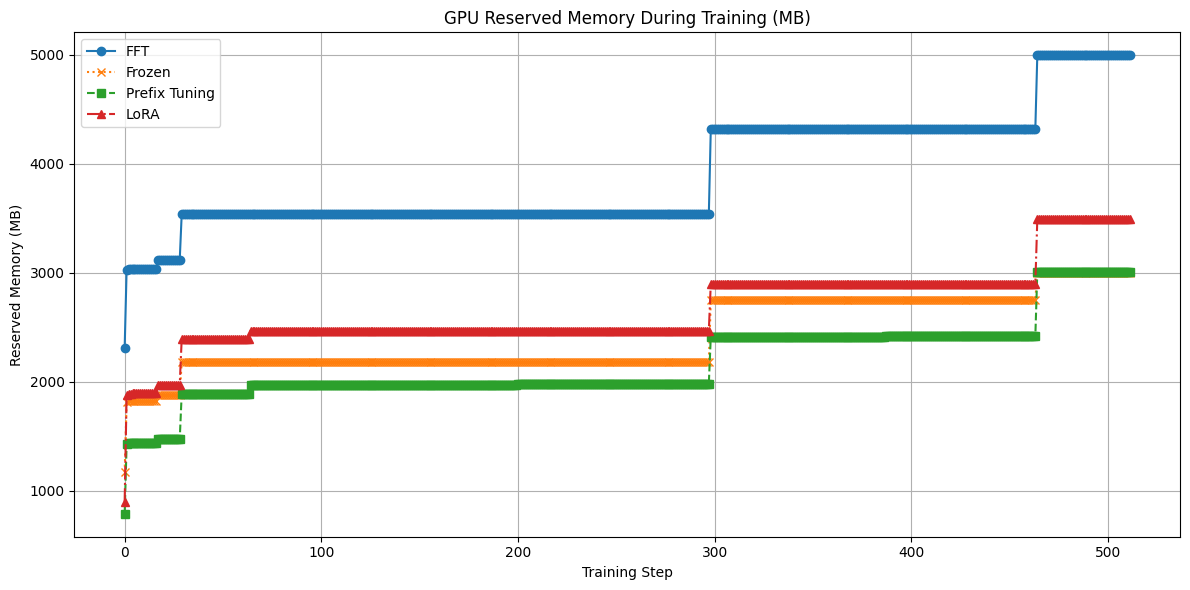

In [23]:
# Plot GPU memory reserved

"""
WRITE HERE YOUR CODE TO PLOT THE MEMORY RESERVED BY EACH MODEL (FROM THE MEMORY LOGGERS)
PLOT ALL 4 MODELS IN THE SAME GRAPH
"""

plt.figure(figsize=(12, 6))

plt.plot(fft_memory_logger.memory_reserved, label='FFT', linestyle='-', marker='o')
plt.plot(frozen_memory_logger.memory_reserved, label='Frozen', linestyle=':', marker='x')
plt.plot(prefix_memory_logger.memory_reserved, label='Prefix Tuning', linestyle='--', marker='s')
plt.plot(lora_memory_logger.memory_reserved, label='LoRA', linestyle='-.', marker='^')


plt.title('GPU Reserved Memory During Training (MB)')
plt.xlabel('Training Step')
plt.ylabel('Reserved Memory (MB)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



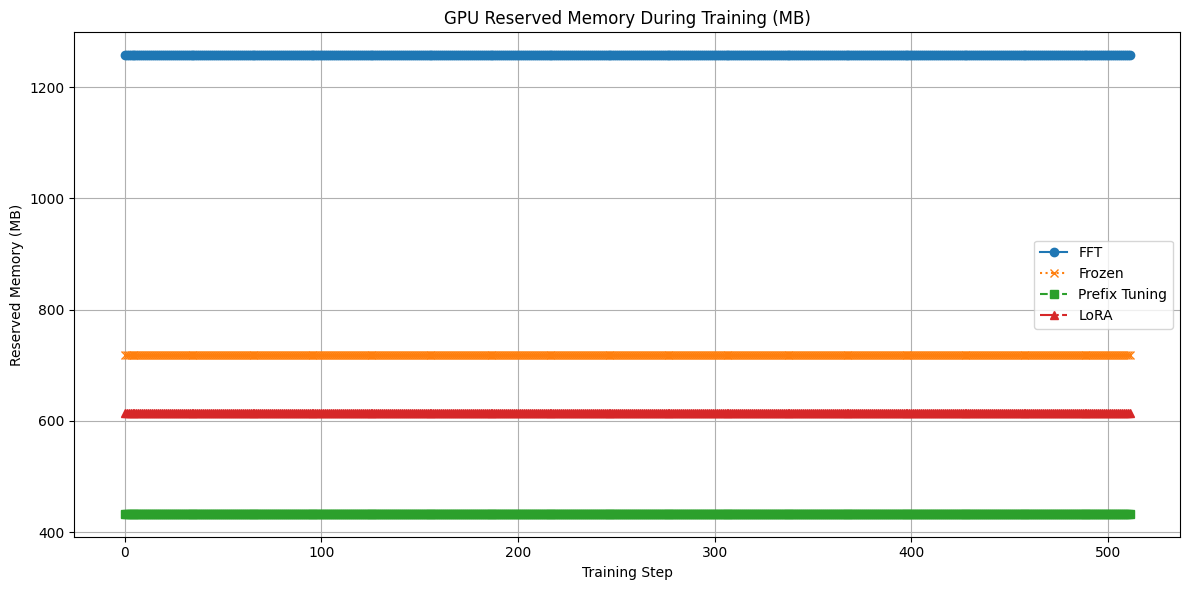

In [24]:
# Plot GPU memory allocated

"""
WRITE HERE YOUR CODE TO PLOT THE MEMORY ALLOCATED BY EACH MODEL (FROM THE MEMORY LOGGERS)
PLOT ALL 4 MODELS IN THE SAME GRAPH
"""

# Plot GPU memory reserved

"""
WRITE HERE YOUR CODE TO PLOT THE MEMORY RESERVED BY EACH MODEL (FROM THE MEMORY LOGGERS)
PLOT ALL 4 MODELS IN THE SAME GRAPH
"""

plt.figure(figsize=(12, 6))

plt.plot(fft_memory_logger.memory_allocated, label='FFT', linestyle='-', marker='o')
plt.plot(frozen_memory_logger.memory_allocated, label='Frozen', linestyle=':', marker='x')
plt.plot(prefix_memory_logger.memory_allocated, label='Prefix Tuning', linestyle='--', marker='s')
plt.plot(lora_memory_logger.memory_allocated, label='LoRA', linestyle='-.', marker='^')


plt.title('GPU Reserved Memory During Training (MB)')
plt.xlabel('Training Step')
plt.ylabel('Reserved Memory (MB)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [31]:
ds['test']

Dataset({
    features: ['text', 'label'],
    num_rows: 1024
})

In [32]:
%pip install ipywidgets --upgrade

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     |████████████████████████████████| 139 kB 2.4 MB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 13.2 MB/s eta 0:00:01
     |████████████████████████████████| 216 kB 79.8 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


## Test

In [38]:
from tqdm import tqdm

In [41]:
def test_function(model_name, model):
    predictions = []
    model.to('cuda')
    for sample in tqdm(ds['test']):
        tokenized_text = tokenizer(sample['text'], return_tensors='pt', truncation=True).to('cuda')
        output = model(tokenized_text['input_ids'])
        predictions.append(output.logits[0].argmax().item())
    model.to('cpu')
    torch.cuda.empty_cache()
    gc.collect()
    report = classification_report(predictions, ds['test']['label'], zero_division=0.0)
    print(f'{model_name} Report:\n{report}')
    return f'{model_name} Report:\n{report}'

In [ ]:
"""
WRITE HERE YOUR CODE TO RUN THE TEST FUNCTION ON EACH MODEL
"""

In [47]:
outFFT = test_function('FFT', fft_model)

100%|██████████| 1024/1024 [00:07<00:00, 142.95it/s]


FFT Report:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80        98
           1       0.78      0.71      0.74        85
           2       0.86      0.72      0.78       110
           3       0.90      0.92      0.91        38
           4       0.71      0.67      0.69        55
           5       0.89      0.81      0.85        95
           6       0.98      0.95      0.97       111
           7       0.89      0.89      0.89        61
           8       0.91      0.93      0.92        87
           9       0.88      0.88      0.88       107
          10       0.61      0.65      0.62        31
          11       0.84      0.89      0.86        36
          12       0.82      0.80      0.81        46
          13       0.23      0.68      0.35        19
          14       0.64      0.88      0.74        26
          15       0.67      0.95      0.78        19

    accuracy                           0.82      1024
   macro avg  

In [46]:
outFrozen = test_function('Frozen', frozen_model)

100%|██████████| 1024/1024 [00:07<00:00, 142.58it/s]


Frozen Report:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80       100
           1       0.77      0.67      0.72        88
           2       0.83      0.72      0.77       106
           3       0.90      0.95      0.92        37
           4       0.60      0.72      0.65        43
           5       0.86      0.75      0.80       100
           6       0.97      0.92      0.95       114
           7       0.84      0.72      0.77        71
           8       0.93      0.89      0.91        93
           9       0.87      0.85      0.86       109
          10       0.58      0.73      0.64        26
          11       0.87      0.85      0.86        39
          12       0.80      0.90      0.85        40
          13       0.25      0.61      0.35        23
          14       0.61      0.88      0.72        25
          15       0.37      1.00      0.54        10

    accuracy                           0.79      1024
   macro av

In [45]:
outPrefix = test_function('Prefix', prefix_model)

100%|██████████| 1024/1024 [00:08<00:00, 126.25it/s]


Prefix Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.01      0.50      0.03         2
           2       0.35      0.12      0.18       258
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.92      0.13      0.23       757
           7       0.00      0.00      0.00         0
           8       0.02      0.33      0.04         6
           9       0.01      1.00      0.02         1
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0

    accuracy                           0.13      1024
   macro av

In [42]:
outLoRA = test_function('LoRA', lora_model)

100%|██████████| 1024/1024 [00:10<00:00, 98.58it/s]


LoRA Report:
              precision    recall  f1-score   support

           0       0.60      0.68      0.63        68
           1       0.01      0.50      0.03         2
           2       0.51      0.57      0.54        82
           3       0.82      0.62      0.70        52
           4       0.00      0.00      0.00         0
           5       0.64      0.39      0.49       142
           6       0.97      0.70      0.81       151
           7       0.62      0.49      0.55        77
           8       0.64      0.59      0.61        97
           9       0.88      0.41      0.56       229
          10       0.00      0.00      0.00         0
          11       0.82      0.30      0.44       103
          12       0.42      0.90      0.58        21
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0

    accuracy                           0.51      1024
   macro avg 